# 📈 Actividad 10 — Reexploración Post-ETL
**CRÍTICO** — Evidencia visual del dataset maestro para la tesis.

Gráficos:
1. Serie temporal: Producción vs Precio (doble eje Y)
2. Heatmap de correlación: Producción × Precio × Emergencias × Noticias
3. Análisis multivariable: Producción × Emergencias × Noticias

In [1]:
%matplotlib inline
import os, sys, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; PROCESSED=DIRS['processed']
REPORTS=DIRS['reports']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


In [2]:

import joblib
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(f"{PROCESSED}/master_dataset_fase1_v2.csv")
scaler_path = f"{DIRS['scalers']}/scaler_fase1_v2.pkl"
cols_sc = [c for c in ['produccion_t','cosecha_ha','precio_chacra_kg',
           'num_emergencias','total_afectados','has_cultivo_perdidas','n_noticias'] if c in df.columns]
if os.path.exists(scaler_path):
    sc = joblib.load(scaler_path)
    df_real = df.copy()
    df_real[cols_sc] = sc.inverse_transform(df[cols_sc].fillna(0))
    print("✅ Scaler cargado — valores desnormalizados para gráficos")
else:
    df_real = df.copy()
print(f"Dataset: {df.shape} | Rango: {df['fecha_evento'].min()} → {df['fecha_evento'].max()}")
display(df.head(3))


✅ Scaler cargado — valores desnormalizados para gráficos
Dataset: (5880, 15) | Rango: 2021-01 → 2025-08


,fecha_evento,departamento,provincia,produccion_t,cosecha_ha,precio_chacra_kg,num_emergencias,total_afectados,has_cultivo_perdidas,n_noticias,anho,mes,trimestre,month_sin,month_cos
0,2021-01,AMAZONAS,BAGUA,-0.197656,0.0,0.156700,2.511802,-0.066273,-0.047940,-1.445097,2021,1,1,0.500000,8.660254e-01
1,2021-02,AMAZONAS,BAGUA,-0.187033,0.0,-0.396299,-0.203660,-0.066273,-0.047940,-1.627361,2021,2,1,0.866025,5.000000e-01
2,2021-03,AMAZONAS,BAGUA,-0.187614,0.0,-0.324667,2.511802,-0.030494,0.093262,-1.080568,2021,3,1,1.000000,6.123234e-17


## 10.1 Serie Temporal — Producción vs Precio

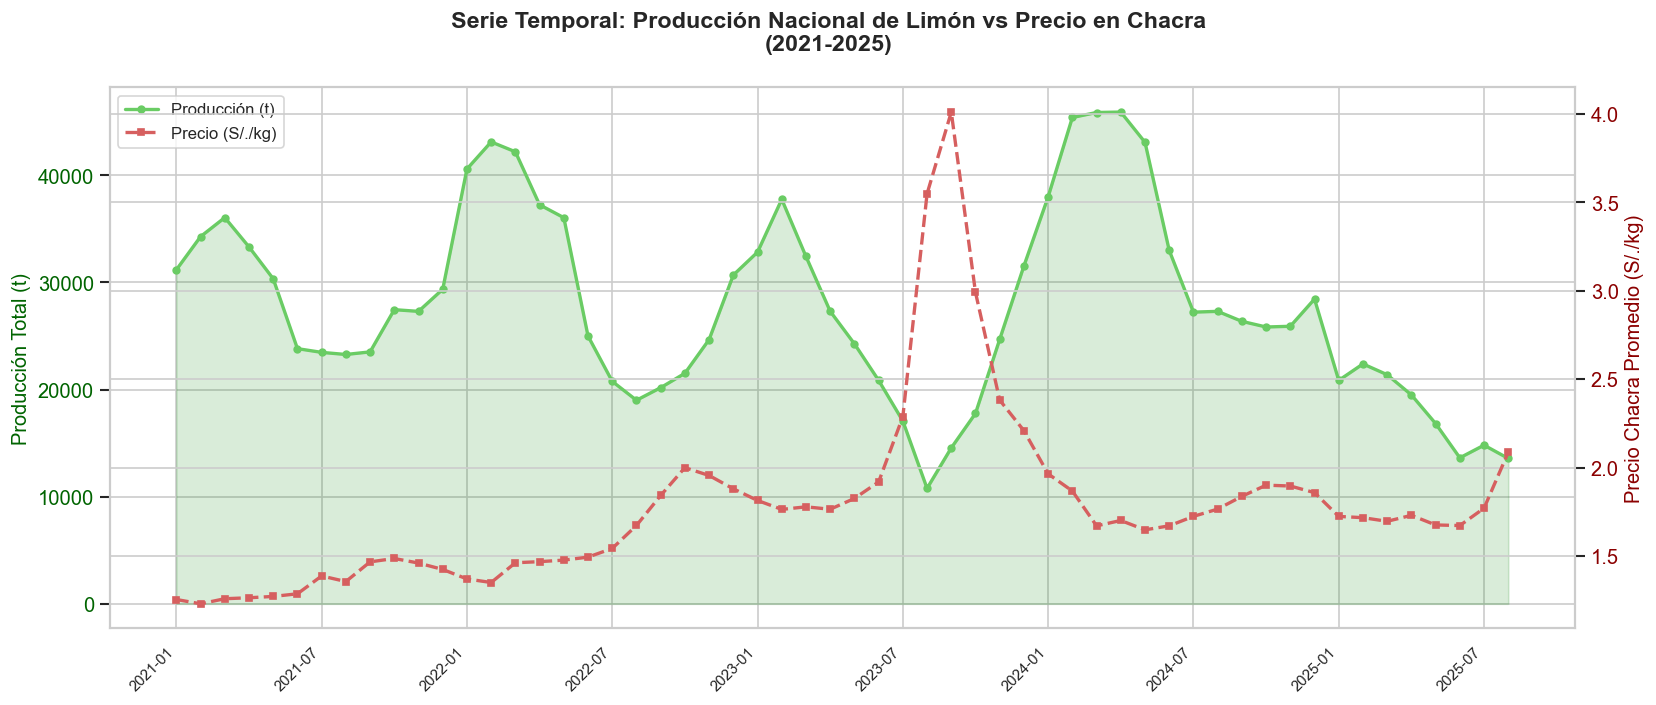

[OK] g10_prod_vs_precio.png


In [3]:

trend = df_real.groupby('fecha_evento').agg(
    prod=('produccion_t','sum'), precio=('precio_chacra_kg','mean')
).reset_index().sort_values('fecha_evento')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.fill_between(range(len(trend)), trend['prod'], alpha=0.15, color='green')
ax1.plot(range(len(trend)), trend['prod'], 'g-o', markersize=4, linewidth=2, label='Producción (t)')
ax1.set_ylabel('Producción Total (t)', color='darkgreen', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.set_xticks(range(0, len(trend), 6))
ax1.set_xticklabels(trend['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(range(len(trend)), trend['precio'], 'r--s', markersize=4, linewidth=2, label='Precio (S/./kg)')
ax2.set_ylabel('Precio Chacra Promedio (S/./kg)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=10)
fig.suptitle('Serie Temporal: Producción Nacional de Limón vs Precio en Chacra\n(2021-2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g10_prod_vs_precio.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g10_prod_vs_precio.png")


## 10.2 Heatmap de Correlación (annot=True)

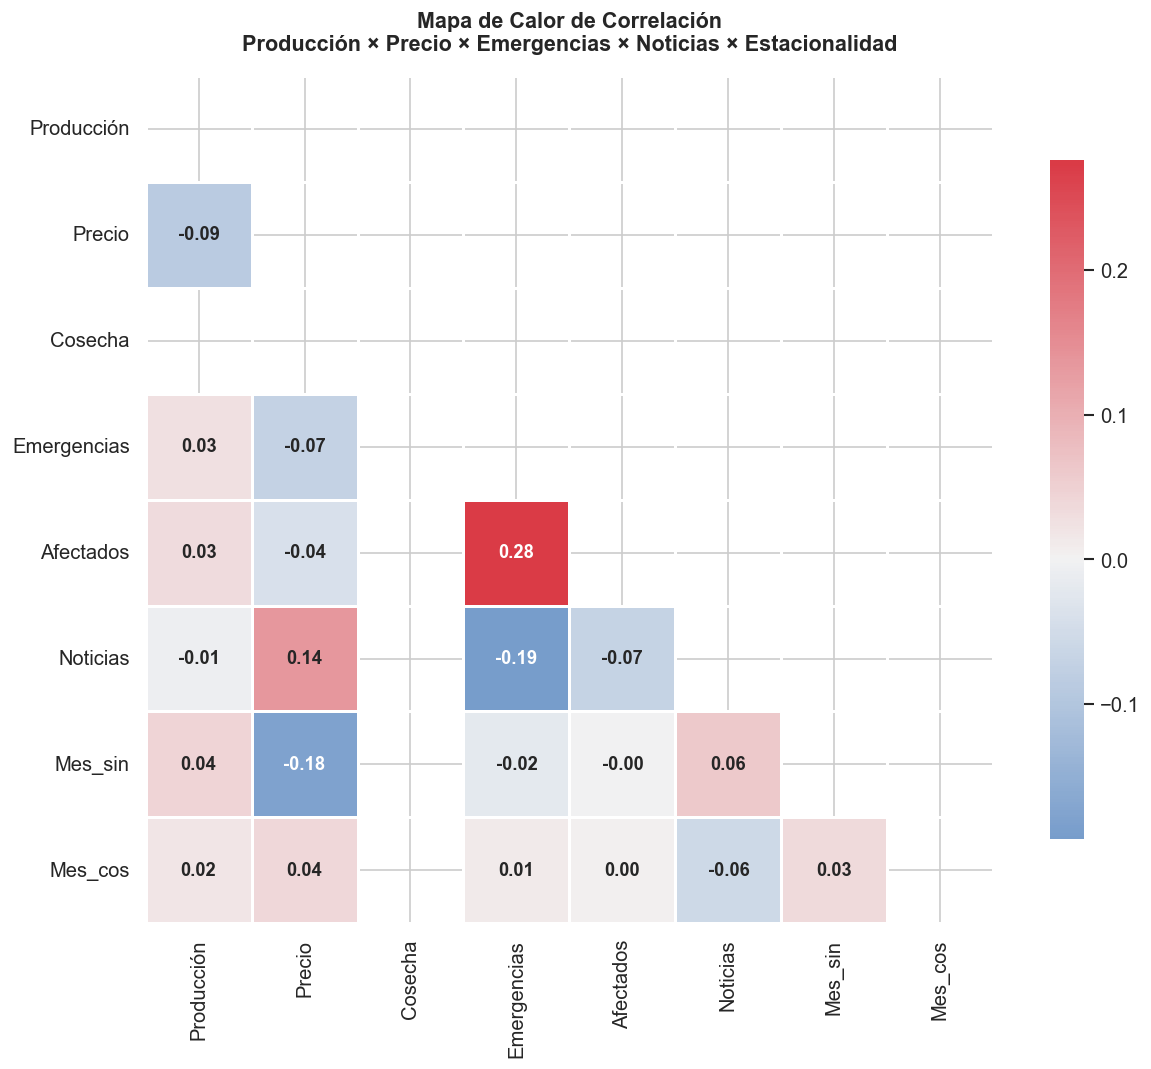

[OK] g11_correlacion_heatmap.png


In [4]:

corr_cols = [c for c in ['produccion_t','precio_chacra_kg','cosecha_ha',
             'num_emergencias','total_afectados','n_noticias',
             'month_sin','month_cos'] if c in df.columns]
corr = df[corr_cols].corr()

labels = {'produccion_t':'Producción','precio_chacra_kg':'Precio','cosecha_ha':'Cosecha',
          'num_emergencias':'Emergencias','total_afectados':'Afectados',
          'n_noticias':'Noticias','month_sin':'Mes_sin','month_cos':'Mes_cos'}
corr.index   = [labels.get(c,c) for c in corr.index]
corr.columns = [labels.get(c,c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.8, cbar_kws={'shrink':0.8},
            annot_kws={'size':11, 'weight':'bold'}, ax=ax)
ax.set_title('Mapa de Calor de Correlación\nProducción × Precio × Emergencias × Noticias × Estacionalidad',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{REPORTS}/g11_correlacion_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g11_correlacion_heatmap.png")


## 10.3 Gráfico Multivariable — Producción × Emergencias × Noticias

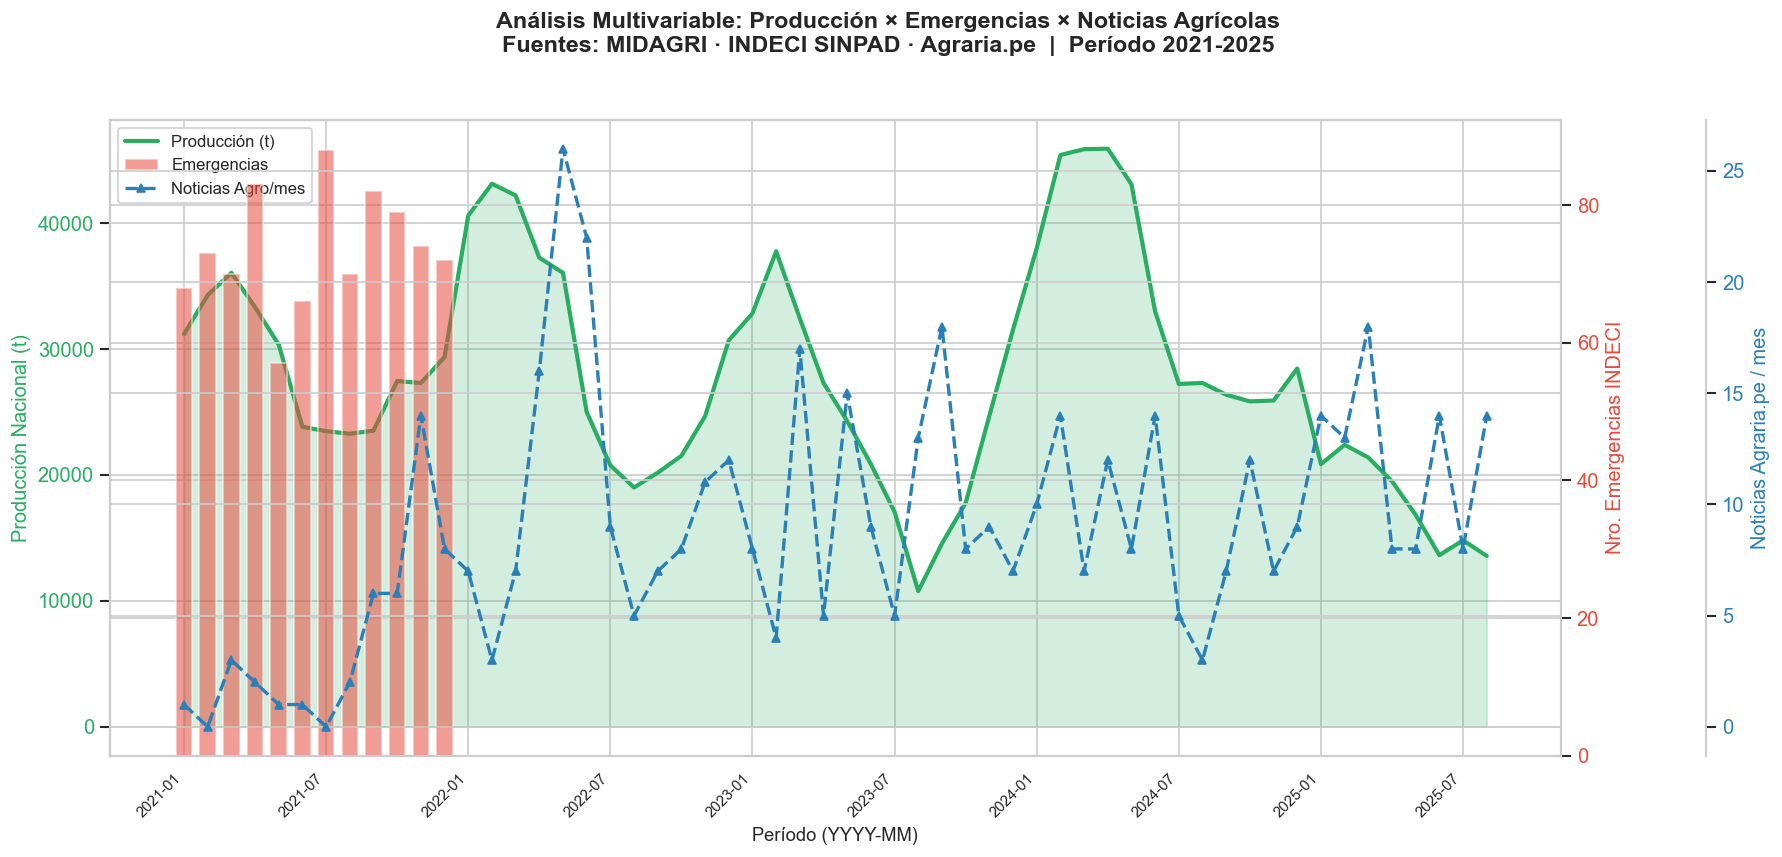

[OK] g12_multivariable.png


In [5]:

multi = df_real.groupby('fecha_evento').agg(
    produccion=('produccion_t','sum'),
    emergencias=('num_emergencias','sum'),
    noticias=('n_noticias','first')
).reset_index().sort_values('fecha_evento')

x = list(range(len(multi)))
fig, ax1 = plt.subplots(figsize=(15, 7))

# Producción — área rellena
ax1.fill_between(x, multi['produccion'], alpha=0.2, color='#27ae60')
ax1.plot(x, multi['produccion'], color='#27ae60', linewidth=2.5, label='Producción (t)')
ax1.set_ylabel('Producción Nacional (t)', color='#27ae60', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#27ae60')
ax1.set_xticks(range(0, len(multi), 6))
ax1.set_xticklabels(multi['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Período (YYYY-MM)', fontsize=11)

# Emergencias — barras
ax2 = ax1.twinx()
ax2.bar(x, multi['emergencias'], alpha=0.55, color='#e74c3c', width=0.7, label='Emergencias')
ax2.set_ylabel('Nro. Emergencias INDECI', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Noticias — línea punteada
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.10))
ax3.plot(x, multi['noticias'], color='#2980b9', linestyle='--', marker='^',
         markersize=5, linewidth=2, label='Noticias Agro/mes')
ax3.set_ylabel('Noticias Agraria.pe / mes', color='#2980b9', fontsize=12)
ax3.tick_params(axis='y', labelcolor='#2980b9')

# Leyenda unificada
handles, labels_list = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    handles += h; labels_list += l
ax1.legend(handles, labels_list, loc='upper left', fontsize=10, framealpha=0.9)

fig.suptitle('Análisis Multivariable: Producción × Emergencias × Noticias Agrícolas\n'
             'Fuentes: MIDAGRI · INDECI SINPAD · Agraria.pe  |  Período 2021-2025',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORTS}/g12_multivariable.png", dpi=150, bbox_inches='tight')
plt.show()
print("[OK] g12_multivariable.png")


## 10.4 Resumen Final del Pipeline

In [6]:

print("=" * 65)
print("  RESUMEN FINAL — PIPELINE FASE 1 EJECUTADO EXITOSAMENTE")
print("=" * 65)
print(f"\n  Dataset maestro: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Rango temporal: {df['fecha_evento'].min()} → {df['fecha_evento'].max()}")
print(f"  Departamentos: {df['departamento'].nunique()}")
print(f"  Provincias:    {df['provincia'].nunique()}")
print()
print("  Columnas del dataset final:")
for c in df.columns:
    print(f"    {c}")
print()
print("  Registros por año:")
for yr, cnt in df.groupby('anho').size().items():
    print(f"    {yr}: {cnt:,} filas")
print("\n✅ [ACTIVIDAD 10] COMPLETADA — FASE 1 FINALIZADA")


  RESUMEN FINAL — PIPELINE FASE 1 EJECUTADO EXITOSAMENTE

  Dataset maestro: 5,880 filas × 15 columnas
  Rango temporal: 2021-01 → 2025-08
  Departamentos: 23
  Provincias:    105

  Columnas del dataset final:
    fecha_evento
    departamento
    provincia
    produccion_t
    cosecha_ha
    precio_chacra_kg
    num_emergencias
    total_afectados
    has_cultivo_perdidas
    n_noticias
    anho
    mes
    trimestre
    month_sin
    month_cos

  Registros por año:
    2021: 1,260 filas
    2022: 1,260 filas
    2023: 1,260 filas
    2024: 1,260 filas
    2025: 840 filas

✅ [ACTIVIDAD 10] COMPLETADA — FASE 1 FINALIZADA


## TODO: INTEGRACIÓN DATA NASA (COMPAÑERO)
Añadir al gráfico multivariable la curva de precipitaciones:
```python
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('axes', 1.22))
ax4.plot(x, multi['precipitacion_mm'], color='#16a085', linestyle=':', linewidth=2, label='Precip. (mm/día)')
ax4.set_ylabel('Precipitación (mm/día)', color='#16a085', fontsize=12)
```
Y en el heatmap, añadir: `T2M`, `PRECTOTCORR`, `RH2M`, `WS2M` a `corr_cols`.
